Imports the pandas library, loads the dataset (hotel_booking_updated.csv) into a DataFrame and displays its first 5 rows

In [47]:
import pandas as pd
df = pd.read_csv(r"C:\Users\LAPAID\Downloads\hotel_booking_updated.csv")
df.head(5)

,hotel,is_canceled,reservation_status_date,lead_time,stays_in_weekend_nights,stays_in_week_nights,market_segment,is_repeated_guest,reserved_room_type,customer_type,average_daily_rate,reservation_status
0,Resort Hotel,0,7/1/2015,342,0,0,Direct,0,C,Transient,0.0,Check-Out
1,Resort Hotel,0,7/1/2015,737,0,0,Direct,0,C,Transient,0.0,Check-Out
2,Resort Hotel,0,7/2/2015,7,0,1,Direct,0,A,Transient,75.0,Check-Out
3,Resort Hotel,0,7/2/2015,13,0,1,Corporate,0,A,Transient,75.0,Check-Out
4,Resort Hotel,0,7/3/2015,14,0,2,Online TA,0,A,Transient,98.0,Check-Out


# Data cleaning

Checks column data types, identifies and removes 38,051 duplicate rows, confirms there are no missing values (NaN), and converts reservation_status_date into a datetime format

In [48]:
df.dtypes

hotel                       object
is_canceled                  int64
reservation_status_date     object
lead_time                    int64
stays_in_weekend_nights      int64
stays_in_week_nights         int64
market_segment              object
is_repeated_guest            int64
reserved_room_type          object
customer_type               object
average_daily_rate         float64
reservation_status          object
dtype: object

In [49]:
df.duplicated().sum()

np.int64(38051)

In [50]:
df= df.drop_duplicates()

In [51]:
df.isna().sum()

hotel                      0
is_canceled                0
reservation_status_date    0
lead_time                  0
stays_in_weekend_nights    0
stays_in_week_nights       0
market_segment             0
is_repeated_guest          0
reserved_room_type         0
customer_type              0
average_daily_rate         0
reservation_status         0
dtype: int64

In [52]:
df["reservation_status_date"]= pd.to_datetime(df["reservation_status_date"],errors="coerce")

In [53]:
df = df[df["average_daily_rate"] >= 0].copy()

# Analysis Question

1. Calculates the average of is_canceled to find the overall hotel booking cancellation rate, which is approximately 28.96%

In [54]:
cancellation_rate = df["is_canceled"].mean()*100
print(f"The overall cancellation rate is {cancellation_rate}%")

The overall cancellation rate is 28.958174530969533%


2. Groups the dataset by hotel type to calculate cancellation statistics—showing a higher cancellation rate for City Hotel (31.86%) than Resort Hotel (24.49%)—and visualizes the comparison using a Seaborn bar plot

In [55]:
df.groupby("hotel")["is_canceled"].agg(["mean","sum","count"])

,mean,sum,count
hotel,,,
City Hotel,0.318556,15722,49354
Resort Hotel,0.244872,7832,31984


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

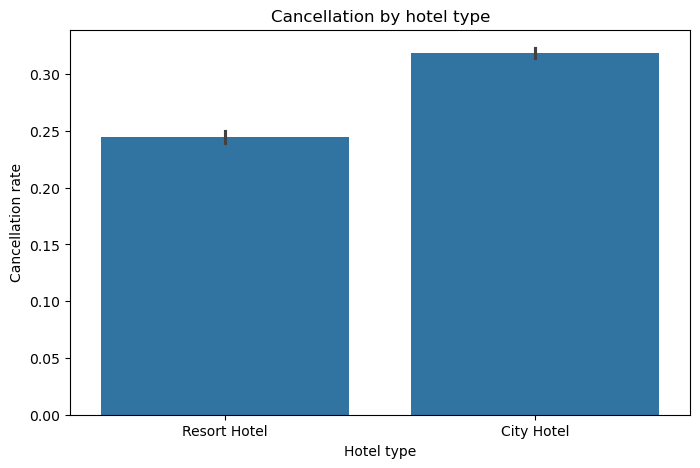

In [57]:
plt.figure(figsize=(8,5))
sns.barplot(data = df, x = "hotel", y = "is_canceled")
plt.title("Cancellation by hotel type")
plt.xlabel("Hotel type")
plt.ylabel("Cancellation rate")
plt.show()

3. Categorizes booking lead times into six tiers (immediate, monthly, medium_term, extended, long_term, very_long_term) using a custom function. Groups the data by lead_time_category to calculate the cancellation rate for each tier, revealing that longer lead times experience higher cancellations (ranging from 8.87% for immediate up to 55.11% for very_long_term). Visualizes these cancellation rates across lead time categories using a bar plot.

In [58]:
def lead_time_categorization(x):
    if x <= 7:
        return ("immediate")
    elif x <= 30:
        return ("monthly")
    elif x <= 90:
        return ("medium_term")
    elif x <= 180:
        return ("extended")
    elif x <= 365:
        return ("long_term")
    else:
        return ("very_long_term")

df["lead_time_category"] = df["lead_time"].apply(lead_time_categorization)

In [59]:
(df.groupby("lead_time_category")[["is_canceled"]].mean()*100).sort_values(by="is_canceled",ascending= False)

,is_canceled
lead_time_category,
very_long_term,55.112219
long_term,43.053207
extended,36.745747
medium_term,33.515815
monthly,26.496559
immediate,8.866305


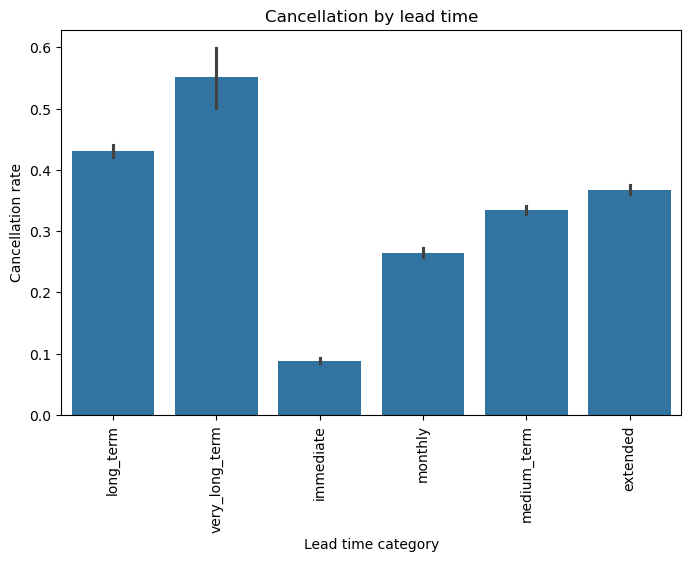

In [60]:
plt.figure(figsize=(8,5))
sns.barplot(data = df, x = "lead_time_category", y = "is_canceled")
plt.title("Cancellation by lead time")
plt.xlabel("Lead time category")
plt.ylabel("Cancellation rate")
plt.xticks(rotation="vertical")
plt.show()

4. Groups data by market_segment to calculate and plot cancellation rates, showing Groups (38.07%) and Online TA (36.07%) have the highest rates, while Corporate (~13.35%) has the lowest

In [61]:
(df.groupby("market_segment")[["is_canceled"]].mean()*100).sort_values(by="is_canceled",ascending= False)

,is_canceled
market_segment,
Undefined,100.000000
Groups,38.078186
Online TA,36.071838
Aviation,21.890547
Offline TA/TO,16.153599
Direct,15.118656
Complementary,13.509317
Corporate,13.353196


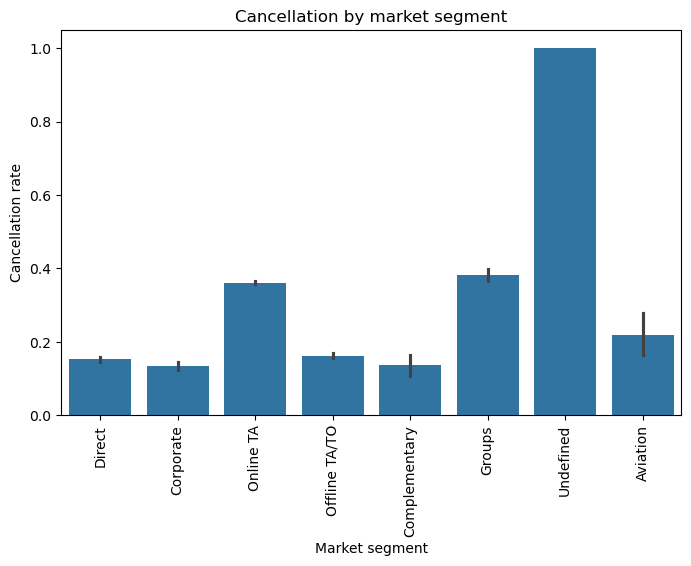

In [62]:
plt.figure(figsize=(8,5))
sns.barplot(data = df, x = "market_segment", y = "is_canceled")
plt.title("Cancellation by market segment")
plt.xlabel("Market segment")
plt.ylabel("Cancellation rate")
plt.xticks(rotation="vertical")
plt.show()

5. Categorizes prices into low, medium, and high ADR groups using quartile thresholds, revealing that higher daily rates lead to higher cancellation rates (high: ~35.08%, medium: ~30.74%, low: ~19.35%)

In [63]:
df["average_daily_rate"].describe()

count    81338.000000
mean       107.603007
std         55.787646
min          0.000000
25%         73.000000
50%         99.000000
75%        135.517500
max       5400.000000
Name: average_daily_rate, dtype: float64

In [64]:
def avg_daily_rate(x):
    if x <= 73:
        return ("low")
    elif x <= 135.90:
        return ("medium")
    else:
        return ("high")

df["adr_group"] = df["average_daily_rate"].apply(avg_daily_rate)

In [65]:
(df.groupby("adr_group")[["is_canceled"]].mean()*100).sort_values(by="is_canceled",ascending= False)

,is_canceled
adr_group,
high,35.081186
medium,30.738880
low,19.348828


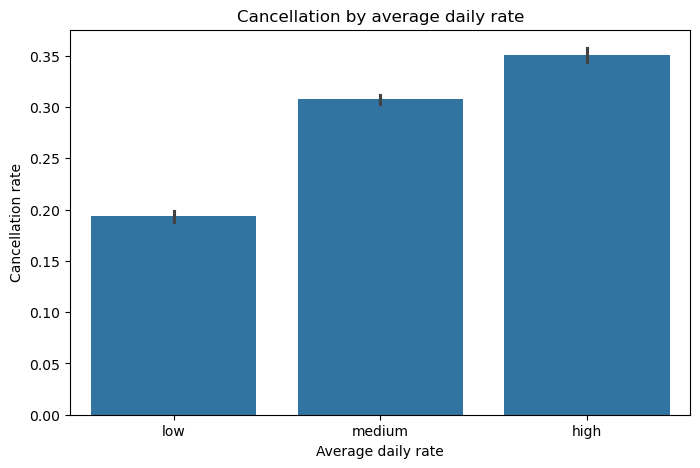

In [66]:
plt.figure(figsize=(8,5))
sns.barplot(data = df, x = "adr_group", y = "is_canceled")
plt.title("Cancellation by average daily rate")
plt.xlabel("Average daily rate")
plt.ylabel("Cancellation rate")
plt.show()

6. Groups bookings by customer_type to analyze cancellation trends, showing Transient customers have the highest cancellation rate (30.71%), while Group customers have the lowest (~10.34%)

In [67]:
(df.groupby("customer_type")[["is_canceled"]].mean()*100).sort_values(by="is_canceled",ascending= False)

,is_canceled
customer_type,
Transient,30.713030
Transient-Party,19.957184
Contract,16.887857
Group,10.344828


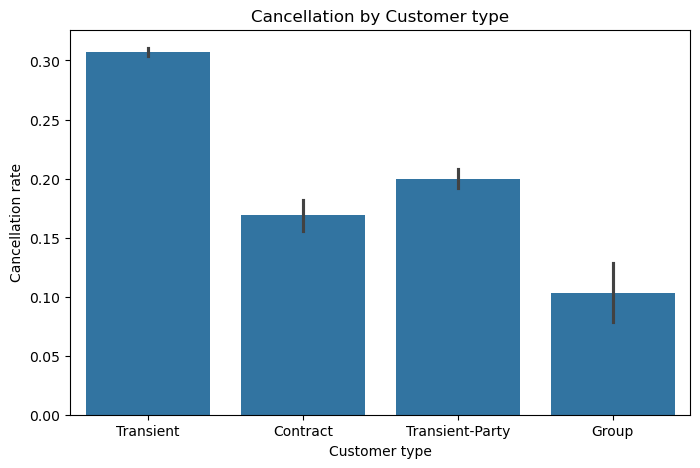

In [68]:
plt.figure(figsize=(8,5))
sns.barplot(data = df, x = "customer_type", y = "is_canceled")
plt.title("Cancellation by Customer type")
plt.xlabel("Customer type")
plt.ylabel("Cancellation rate")
plt.show()

7. Analyzes cancellation rates across reserved room types, showing Room Type P has a 100% cancellation rate, followed by H (40.67%) and G (36.09%), while E (27.76%) and A (27.87%) have the lowest rates

In [69]:
(df.groupby("reserved_room_type")[["is_canceled"]].mean()*100).sort_values(by="is_canceled",ascending= False)

,is_canceled
reserved_room_type,
P,100.000000
H,40.672269
G,36.094675
B,33.409874
L,33.333333
C,32.850780
D,30.728762
F,30.417567
A,27.873970


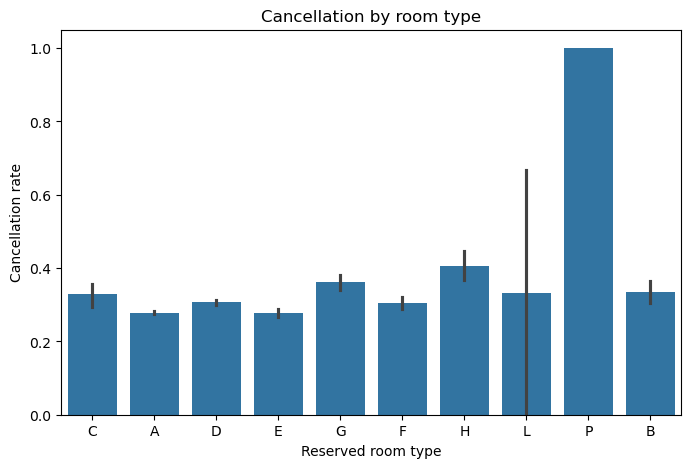

In [70]:
plt.figure(figsize=(8,5))
sns.barplot(data = df, x = "reserved_room_type", y = "is_canceled")
plt.title("Cancellation by room type")
plt.xlabel("Reserved room type")
plt.ylabel("Cancellation rate")
plt.show()

8. Categorizes guests into new vs. repeated guests (is_repeated_guest), revealing that new_guest bookings have a significantly higher cancellation rate (29.82%) compared to repeated_guest bookings (7.98%)

In [71]:
def guest_type(x):
    if x==1:
        return("repeated_guest")
    else:
        return("new_guest")

df["category_of_customer_type"] = df["is_repeated_guest"].apply(guest_type)

In [72]:

df.groupby("category_of_customer_type")[["is_canceled"]].mean()*100

,is_canceled
category_of_customer_type,
new_guest,29.815850
repeated_guest,7.981221


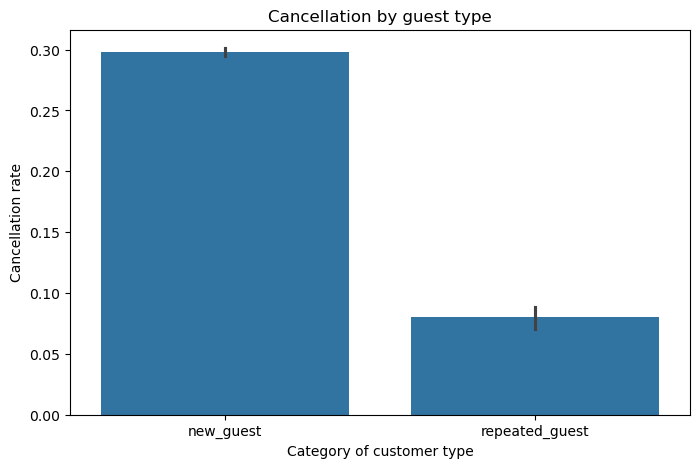

In [73]:
plt.figure(figsize=(8,5))
sns.barplot(data = df, x = "category_of_customer_type", y = "is_canceled")
plt.title("Cancellation by guest type")
plt.xlabel("Category of customer type")
plt.ylabel("Cancellation rate")
plt.show()

9. Extracts year and month from reservation_status_date to calculate monthly cancellation rates across 2014–2017 and plots the trend, showing high rates during early winter and dips around late summer

In [74]:
df["year"] = df["reservation_status_date"].dt.year
df["month"] = df["reservation_status_date"].dt.month

In [75]:
df.groupby(["year","month"])[["is_canceled"]].mean()*100

is_canceled
year month             
2014 10      100.000000
     11      100.000000
2015 1       100.000000
     2       100.000000
     3       100.000000
     4       100.000000
     5       100.000000
     6       100.000000
     7        32.464631
     8        19.249513
     9        18.209607
     10       19.074908
     11       20.454545
     12       23.553965
2016 1        37.324790
     2        35.256817
     3        32.795699
     4        31.030641
     5        28.438500
     6        29.963009
     7        27.408009
     8        26.740506
     9        28.780758
     10       29.281617
     11       28.038440
     12       35.215714
2017 1        41.381279
     2        39.088319
     3        34.479979
     4        30.191295
     5        28.801020
     6        20.613236
     7        17.950989
     8         8.927968
     9         0.000000

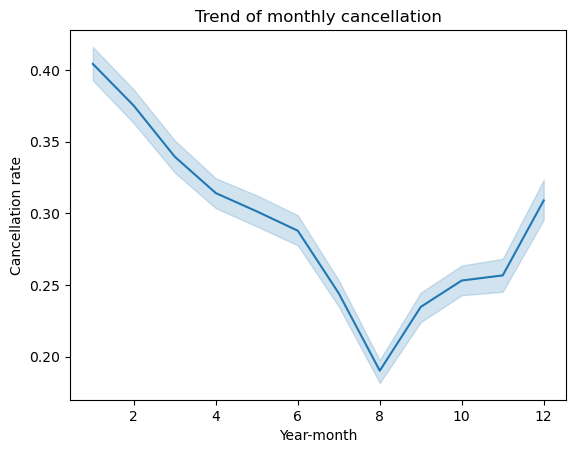

In [76]:
sns.lineplot(data=df, x= "month", y="is_canceled")
plt.title("Trend of monthly cancellation")
plt.xlabel("Year-month")
plt.ylabel("Cancellation rate")
plt.show()

10. Calculates completed booking revenue (average_daily_rate * total_stays where is_canceled == 0), aggregates it by year and month, and visualizes monthly revenue trends to highlight peak summer seasonality

In [77]:
df["total_stays"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

In [78]:
df["revenue"] = df["average_daily_rate"] * df["total_stays"]

In [79]:
df_revenue = df[df["is_canceled"]==0]

In [80]:
df.groupby(["year","month"])[["revenue"]].sum()

revenue
year month            
2014 10        1130.40
     11           0.00
2015 1        14462.37
     2        18209.98
     3        22585.45
     4        59420.10
     5        96640.65
     6       190439.56
     7       707501.18
     8      1147758.83
     9       931886.52
     10      687750.71
     11      363445.20
     12      363082.30
2016 1       679053.36
     2       851248.58
     3      1170649.49
     4      1184713.21
     5      1259145.40
     6      1366514.46
     7      1922918.98
     8      2141310.49
     9      1585731.52
     10     1249464.70
     11     1075199.69
     12      853635.97
2017 1      1243908.89
     2      1168777.94
     3      1348566.66
     4      1602732.49
     5      1700066.28
     6      1600197.34
     7      1964711.28
     8      2011432.00
     9       260910.26

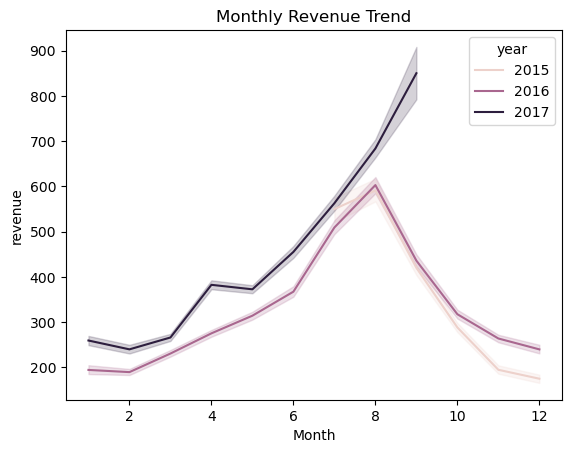

In [81]:
sns.lineplot(data=df_revenue, x="month", y="revenue", hue="year")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("revenue")
plt.show()

11. Filters for cancelled bookings (is_canceled == 1), calculates the total lost revenue ($11,303,135.83), and plots monthly trends of potential revenue lost per year

In [82]:
df_canceled = df[df["is_canceled"]==1].copy()

In [83]:
df_canceled["potential_revenues"] = df_canceled["average_daily_rate"] * df_canceled["total_stays"]

In [84]:
total_potential_rev_lost = df_canceled["potential_revenues"].sum()
print(f"Total potential revenue lost from cancellation is {total_potential_rev_lost}")

Total potential revenue lost from cancellation is 11303135.83


In [85]:
monthly_rev_lost= df_canceled.groupby(["year","month"])["potential_revenues"].sum()

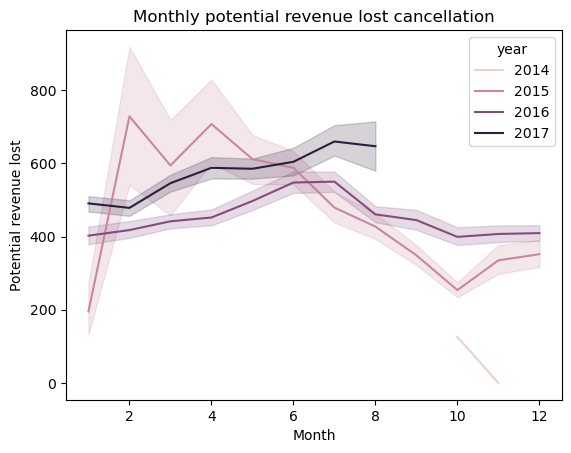

In [86]:
sns.lineplot(data= df_canceled, x="month", y="potential_revenues", hue="year")
plt.title("Monthly potential revenue lost cancellation")
plt.xlabel("Month")
plt.ylabel("Potential revenue lost")
plt.show()

12. Encodes categorical features (hotel, market_segment, customer_type, reserved_room_type) into numerical labels, fits a Multiple Linear Regression model using lead time, stays, and the encoded columns to predict average_daily_rate. Using an 80/20 train-test split, the model achieves Train R² ≈ 0.207 and Test R² ≈ 0.237 — modest but stable, meaning ADR is only partially explained by these features.

In [87]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['hotel_n'] = le.fit_transform(df['hotel'])
df['market_n'] = le.fit_transform(df['market_segment'])
df['customer_n'] = le.fit_transform(df['customer_type'])
df['room_n'] = le.fit_transform(df['reserved_room_type'])

In [88]:
X = df[["lead_time","stays_in_week_nights","stays_in_weekend_nights","hotel_n","market_n","customer_n","room_n"]]
y= df["average_daily_rate"]

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split data so we test on rows the model hasn't seen
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print(f"Train R²: {model.score(X_train, y_train):.3f}")
print(f"Test R²:  {model.score(X_test, y_test):.3f}")

Train R²: 0.207
Test R²:  0.237


Key Findings

- Overall cancellation rate: ~29%
- City hotels cancel more than Resort hotels (31.9% vs 24.5%)
- Longer lead time → higher cancellation. Immediate: 8.9%. Very long-term (365+ days): 55.1%
- Highest cancellation by market segment: Groups (38.1%) and Online TA (36.1%); lowest: Corporate (~13%)
- Higher ADR bookings cancel more (high: 35.1%, low: 19.3%)
- New guests cancel far more than repeat guests (29.8% vs 8.0%)
- Total potential revenue lost to cancellations: $11,303,135.83
- Monthly revenue peaks in Aug (summer seasonality); cancellations are highest in Jan
- Linear regression predicting ADR from lead time, stays, and encoded categoricals: Train R² ≈ 0.21, Test R² ≈ 0.24 — modest but stable, meaning ADR is only partially explained by these features

Tools Used

Python, pandas, seaborn, matplotlib, scikit-learn (LabelEncoder, LinearRegression, train_test_split)